# 01 — English dataset EDA (supporting / appendix)

**Role:** exploratory **reference** for the **raw** Kaggle dataset `rayyankauchali0/resume-dataset`. This notebook is **not** the benchmark pipeline: cleaning, audited mapping, coverage, and splits are in **`32_english_dataset_alignment.ipynb`**; a softer eval slice is **`54_english_balanced_8class_eval.ipynb`**.

Use **01** for **schema**, **source mix**, **raw categories**, and **text length**. Treat any ontology list printed here as **background context** only—the **authoritative** mapping is in **32**.

**Outputs:** `notebooks/results/english_dataset_eda/` · `figures/english_dataset_eda/`

Default flow: run top-to-bottom (requires `kagglehub` and network for download).


In [1]:
# Ensure kagglehub is installed before importing, to avoid ModuleNotFoundError
try:
    import kagglehub
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install --quiet kagglehub
    import kagglehub

/Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json
import zipfile
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", 50)

CWD = Path.cwd()
NOTEBOOK_DIR = CWD if CWD.name == "notebooks" else (CWD / "notebooks")
REPO_ROOT = NOTEBOOK_DIR.parent
RESULTS_DIR = REPO_ROOT / "notebooks" / "results" / "english_dataset_eda"
FIGURES_DIR = REPO_ROOT / "figures" / "english_dataset_eda"
for _d in (RESULTS_DIR, FIGURES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ModuleNotFoundError:
    HAS_MPL = False



In [3]:
KAGGLE_HANDLE = "rayyankauchali0/resume-dataset"

# Download latest version
path = kagglehub.dataset_download(KAGGLE_HANDLE)
downloaded_path = Path(path)

print("Path to dataset files:", downloaded_path)

SEARCH_DIRS = [
    downloaded_path if downloaded_path.is_dir() else downloaded_path.parent,
]

KNOWN_FILENAMES = {
    "tech_resumes_dataset.jsonl",
    "Resume_Dataset.zip",
    "resume-dataset.zip",
}

def find_candidate_files(search_dirs):
    candidates = []
    for base in search_dirs:
        if not base.exists():
            continue
        for path in base.rglob("*"):
            if not path.is_file():
                continue
            if path.name in KNOWN_FILENAMES or path.suffix.lower() in {".jsonl", ".csv", ".zip"}:
                candidates.append(path)
    return sorted(set(candidates))

candidates = find_candidate_files(SEARCH_DIRS)

print("Search dirs:")
for d in SEARCH_DIRS:
    print(" -", d)
print("\nCandidates:")
for c in candidates[:30]:
    print(" -", c)

if not candidates:
    raise FileNotFoundError("No dataset file found in the downloaded Kaggle dataset directory")


Path to dataset files: /Users/natashaagapova/.cache/kagglehub/datasets/rayyankauchali0/resume-dataset/versions/1
Search dirs:
 - /Users/natashaagapova/.cache/kagglehub/datasets/rayyankauchali0/resume-dataset/versions/1

Candidates:
 - /Users/natashaagapova/.cache/kagglehub/datasets/rayyankauchali0/resume-dataset/versions/1/resumes_dataset.jsonl


In [4]:
def load_jsonl(path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

def load_from_zip(path):
    with zipfile.ZipFile(path) as zf:
        names = zf.namelist()
        jsonl_names = [n for n in names if n.lower().endswith('.jsonl')]
        csv_names = [n for n in names if n.lower().endswith('.csv')]

        if jsonl_names:
            target = jsonl_names[0]
            with zf.open(target) as f:
                rows = [json.loads(line.decode('utf-8')) for line in f if line.strip()]
            return pd.DataFrame(rows), target

        if csv_names:
            target = csv_names[0]
            with zf.open(target) as f:
                return pd.read_csv(f), target

        raise FileNotFoundError("No .jsonl or .csv found inside archive")

dataset_path = None
dataset_inner_name = None
df = None

for candidate in candidates:
    try:
        if candidate.suffix.lower() == ".jsonl":
            df = load_jsonl(candidate)
            dataset_path = candidate
            break
        if candidate.suffix.lower() == ".csv":
            df = pd.read_csv(candidate)
            dataset_path = candidate
            break
        if candidate.suffix.lower() == ".zip":
            df, dataset_inner_name = load_from_zip(candidate)
            dataset_path = candidate
            break
    except Exception as exc:
        print(f"Skipping {candidate}: {exc}")

if df is None:
    raise RuntimeError("Found candidate files, but failed to load any dataset")

print("Loaded from:", dataset_path)
if dataset_inner_name is not None:
    print("Inner file:", dataset_inner_name)
print("Shape:", df.shape)


Loaded from: /Users/natashaagapova/.cache/kagglehub/datasets/rayyankauchali0/resume-dataset/versions/1/resumes_dataset.jsonl
Shape: (3500, 12)


In [5]:
print("Columns:")
for col in df.columns:
    print(" -", col)

display(df.head(3))
display(df.isna().mean().sort_values(ascending=False).to_frame("missing_share").head(20))


Columns:
 - ResumeID
 - Category
 - Name
 - Email
 - Phone
 - Location
 - Summary
 - Skills
 - Experience
 - Education
 - Text
 - Source


,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 2014 102011 112013 092008 102011 ...,"City, State",jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professi...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professi...,Computer Science degree,jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professi...,ResumeAtlas
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 30 70 30 40 ...,"City, State",jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailcom twittercomjamaica enthusiastic wellorganized java deve...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailcom twittercomjamaica enthusiastic wellorganized java deve...,Computer Science degree,jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailcom twittercomjamaica enthusiastic wellorganized java deve...,ResumeAtlas
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 2 052017 2 5 253 5 092021 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary almost 8 years experience delivering enterprise solutio...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary almost 8 years experience delivering enterprise solutio...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary almost 8 years experience delivering enterprise solutio...,ResumeAtlas


,missing_share
ResumeID,0.0
Category,0.0
Name,0.0
Email,0.0
Phone,0.0
Location,0.0
Summary,0.0
Skills,0.0
Experience,0.0
Education,0.0


In [6]:
TEXT_CANDIDATES = ["Resume_Text", "resume_text", "Summary", "Experience", "Education", "Skills"]
CATEGORY_CANDIDATES = ["Category", "category", "Job_Role", "job_role"]
LOCATION_CANDIDATES = ["Location", "location", "City", "city"]
SOURCE_CANDIDATES = ["Source", "source"]

def first_existing(candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

category_col = first_existing(CATEGORY_CANDIDATES)
location_col = first_existing(LOCATION_CANDIDATES)
source_col = first_existing(SOURCE_CANDIDATES)
resume_text_col = first_existing(TEXT_CANDIDATES)

if resume_text_col is None:
    text_parts = [c for c in ["Summary", "Skills", "Experience", "Education"] if c in df.columns]
    if text_parts:
        df["resume_text"] = df[text_parts].fillna("").astype(str).agg("\n\n".join, axis=1)
        resume_text_col = "resume_text"

print("category_col:", category_col)
print("location_col:", location_col)
print("source_col:", source_col)
print("resume_text_col:", resume_text_col)

if resume_text_col is None:
    raise KeyError("Could not find or construct a resume text column")


category_col: Category
location_col: Location
source_col: Source
resume_text_col: Summary


In [7]:
df["resume_text_work"] = df[resume_text_col].fillna("").astype(str)
df["text_len_chars"] = df["resume_text_work"].str.len()
df["text_len_words"] = df["resume_text_work"].str.split().str.len()

summary = {
    "n_rows": len(df),
    "n_cols": len(df.columns),
    "empty_text_share": float((df["resume_text_work"].str.strip() == "").mean()),
    "median_chars": float(df["text_len_chars"].median()),
    "median_words": float(df["text_len_words"].median()),
    "p10_words": float(df["text_len_words"].quantile(0.10)),
    "p90_words": float(df["text_len_words"].quantile(0.90)),
}
pd.DataFrame([summary]).to_csv(RESULTS_DIR / "01_english_eda_text_stats.csv", index=False)
(RESULTS_DIR / "01_english_eda_text_stats.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)
summary



{'n_rows': 3500,
 'n_cols': 15,
 'empty_text_share': 0.0,
 'median_chars': 203.0,
 'median_words': 23.0,
 'p10_words': 21.0,
 'p90_words': 27.0}

In [8]:
if category_col is not None:
    cat_counts = df[category_col].value_counts(dropna=False)
    display(cat_counts.head(30).to_frame("count"))
    print("Unique categories:", df[category_col].nunique(dropna=True))
    cat_counts.to_csv(RESULTS_DIR / "01_english_eda_category_counts.csv")

if source_col is not None:
    source_counts = df[source_col].value_counts(dropna=False)
    display(source_counts.to_frame("count"))
    if source_counts.sum() > 0:
        display((source_counts / source_counts.sum()).round(4).to_frame("share"))
    source_counts.to_csv(RESULTS_DIR / "01_english_eda_source_counts.csv")

if location_col is not None:
    loc_counts = df[location_col].astype(str).value_counts(dropna=False)
    display(loc_counts.head(30).to_frame("count"))
    print("Unique locations:", df[location_col].nunique(dropna=True))
    loc_counts.head(200).to_csv(RESULTS_DIR / "01_english_eda_location_counts_top200.csv")



,count
Category,
Java Developer,200
Python Developer,200
Data Science,200
DevOps,180
SQL Developer,180
Database,150
Testing,150
Web Designing,150
React Developer,150


Unique categories: 36


,count
Source,
ResumeAtlas,2337
Synthetic,1163


,share
Source,
ResumeAtlas,0.6677
Synthetic,0.3323


,count
Location,
"City, State",2337
"East William, AK",1
"East Susan, MA",1
"North Donnaport, CO",1
"Grayside, IN",1
"Wilkersonmouth, FL",1
"Port Danielburgh, WY",1
"Smithview, NY",1
"West Natashaport, IA",1


Unique locations: 1164


In [9]:
sample_cols = [c for c in [category_col, location_col, source_col, "Summary", "Skills", "Experience", "Education", "resume_text_work"] if c is not None and c in df.columns]
sample_df = df[sample_cols].sample(min(8, len(df)), random_state=42)
display(sample_df)


,Category,Location,Source,Summary,Skills,Experience,Education,resume_text_work
1650,DotNet Developer,"City, State",ResumeAtlas,robert smith dot net developer internship infoqwikresumecom linkedin profile qwikresumecom dot net developer 1 plus years experience designing developing im...,"Python, SQL, Git, Linux",robert smith dot net developer internship infoqwikresumecom linkedin profile qwikresumecom dot net developer 1 plus years experience designing developing im...,Computer Science degree,robert smith dot net developer internship infoqwikresumecom linkedin profile qwikresumecom dot net developer 1 plus years experience designing developing im...
2456,Software Developer,"New Marc, LA",Synthetic,"Experienced Software Developer with 9+ years building scalable web applications and software solutions. Expertise in full-stack development, API design, and...","MongoDB, React, Node.js, REST API, Docker, JavaScript, SQL, Java, Python, AWS, Git, Agile",Senior Software Engineer at Oracle (2020 - 2024): Improved system performance by 20% through optimization techniques; Implemented CI/CD pipelines reducing d...,"Master of Engineering in Software Engineering from University of Michigan, 2015, GPA: 3.94","Experienced Software Developer with 9+ years building scalable web applications and software solutions. Expertise in full-stack development, API design, and..."
2232,Business Analyst,"City, State",ResumeAtlas,kaitlyn riley business details address new york ny united states profile dedicated business analyst strong understanding finance operational proficiency bus...,"Python, SQL, Git, Linux",kaitlyn riley business details address new york ny united states profile dedicated business analyst strong understanding finance operational proficiency bus...,Computer Science degree,kaitlyn riley business details address new york ny united states profile dedicated business analyst strong understanding finance operational proficiency bus...
1945,SAP Developer,"City, State",ResumeAtlas,nabhi saheb shaik phone number 918886057704918341843550 mail id sknabhi477gmailcom professional summary total 42 years 33 years sap fico experience good exp...,"Python, SQL, Git, Linux",nabhi saheb shaik phone number 918886057704918341843550 mail id sknabhi477gmailcom professional summary total 42 years 33 years sap fico experience good exp...,Computer Science degree,nabhi saheb shaik phone number 918886057704918341843550 mail id sknabhi477gmailcom professional summary total 42 years 33 years sap fico experience good exp...
309,Python Developer,"City, State",ResumeAtlas,jessica claire 100 montgomery st 10th floor 555 4321000 resumesampleexamplecom summary driven results business intelligence professional 9 experience data m...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor 555 4321000 resumesampleexamplecom summary driven results business intelligence professional 9 experience data m...,Computer Science degree,jessica claire 100 montgomery st 10th floor 555 4321000 resumesampleexamplecom summary driven results business intelligence professional 9 experience data m...
2341,Software Developer,"Wilkersonmouth, FL",Synthetic,"Experienced Software Developer with 3+ years building scalable web applications and software solutions. Expertise in full-stack development, API design, and...","Java, Git, React, Docker, Microservices, Node.js, AWS, PostgreSQL, Python, JavaScript, MongoDB, Git",Software Developer at Tesla (2022 - 2024): Developed and maintained 15 production applications serving 132K+ users; Collaborated with cross-functional teams...,"Master of Science in Data Science from UCLA, 2014, GPA: 3.24","Experienced Software Developer with 3+ years building scalable web applications and software solutions. Expertise in full-stack development, API design, and..."
1666,DotNet Developer,"City, State",ResumeAtlas,jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary handson microsoft net applicati

In [10]:
# Project ontology target names (reference only; audited mapping lives in notebook 32).
TARGET_9_CLASSES = [
    "backend_general_dev",
    "web_frontend",
    "sysadmin_devops_network",
    "project_product",
    "sales_account",
    "tech_support_helpdesk",
    "it_governance_leadership",
    "technical_specialized",
    "generic_it_ops",
]

print("Target classes in project ontology (see 32 for English coverage):")
for c in TARGET_9_CLASSES:
    print(" -", c)

if category_col is not None:
    unique_cats = sorted(df[category_col].dropna().astype(str).unique())
    print("\nFirst 60 raw English categories:")
    for c in unique_cats[:60]:
        print(" -", c)



Target classes in project ontology (see 32 for English coverage):
 - backend_general_dev
 - web_frontend
 - sysadmin_devops_network
 - project_product
 - sales_account
 - tech_support_helpdesk
 - it_governance_leadership
 - technical_specialized
 - generic_it_ops

First 60 raw English categories:
 - AI Engineer
 - Backend Developer
 - Blockchain
 - Blockchain Developer
 - Business Analyst
 - Cloud Engineer
 - Cybersecurity Analyst
 - Data Science
 - Database
 - Database Administrator
 - DevOps
 - Digital Media
 - DotNet Developer
 - ETL Developer
 - Engineering Manager
 - Frontend Developer
 - Full Stack Developer
 - Java Developer
 - Machine Learning Engineer
 - Mobile Developer
 - Network Security Engineer
 - Principal Engineer
 - Product Manager
 - Python Developer
 - QA Engineer
 - React Developer
 - SAP Developer
 - SQL Developer
 - Site Reliability Engineer
 - Software Developer
 - System Administrator
 - Technical Lead
 - Technical Writer
 - Testing
 - UI/UX Designer
 - Web Desi

In [11]:
checks = []

checks.append({
    "check": "Has explicit category column",
    "status": category_col is not None,
})
checks.append({
    "check": "Has explicit location column",
    "status": location_col is not None,
})
checks.append({
    "check": "Has explicit source column",
    "status": source_col is not None,
})
checks.append({
    "check": "Median text length >= 80 words",
    "status": summary["median_words"] >= 80,
})

if source_col is not None:
    synthetic_like = df[source_col].astype(str).str.lower().isin(["template", "llm", "faker"]).mean()
    checks.append({
        "check": "Synthetic-like share < 0.70",
        "status": synthetic_like < 0.70,
        "value": round(float(synthetic_like), 4),
    })

checks_df = pd.DataFrame(checks)
display(checks_df)
checks_df.to_csv(RESULTS_DIR / "01_english_eda_readiness_checks.csv", index=False)

eda_manifest = {
    "notebook": "01_english_dataset_eda.ipynb",
    "role": "english_dataset_exploratory_appendix",
    "results_dir": str(RESULTS_DIR),
    "figures_dir": str(FIGURES_DIR),
    "canonical_benchmark_notebook": "notebooks/32_english_dataset_alignment.ipynb",
    "exports": [
        "01_english_eda_text_stats.csv",
        "01_english_eda_text_stats.json",
        "01_english_eda_category_counts.csv",
        "01_english_eda_source_counts.csv",
        "01_english_eda_location_counts_top200.csv",
        "01_english_eda_readiness_checks.csv",
        "01_english_eda_manifest.json",
    ],
}
(RESULTS_DIR / "01_english_eda_manifest.json").write_text(
    json.dumps(eda_manifest, indent=2, ensure_ascii=False),
    encoding="utf-8",
)




,check,status,value
0,Has explicit category column,True,NaN
1,Has explicit location column,True,NaN
2,Has explicit source column,True,NaN
3,Median text length >= 80 words,False,NaN
4,Synthetic-like share < 0.70,True,0.0


724

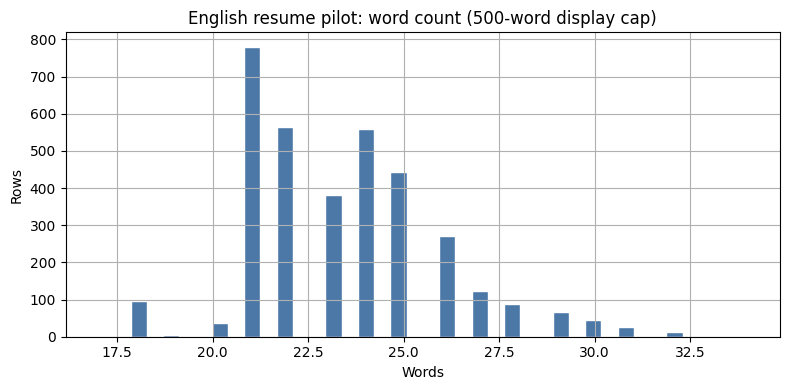

In [12]:
if HAS_MPL and len(df):
    fig, ax = plt.subplots(figsize=(8, 4))
    df["text_len_words"].clip(upper=500).hist(bins=40, ax=ax, color="#4c78a8", edgecolor="white")
    ax.set_title("English resume pilot: word count (500-word display cap)")
    ax.set_xlabel("Words")
    ax.set_ylabel("Rows")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "01_english_eda_word_count_hist.png", dpi=160, bbox_inches="tight")
    plt.show()
    try:
        man = json.loads((RESULTS_DIR / "01_english_eda_manifest.json").read_text(encoding="utf-8"))
        man["figure_exports"] = ["01_english_eda_word_count_hist.png"]
        (RESULTS_DIR / "01_english_eda_manifest.json").write_text(
            json.dumps(man, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
    except Exception:
        pass
else:
    print("matplotlib not available; skip word-count figure.")



In [13]:
print("Quick verdict (EDA only; benchmark = notebook 32):")
print("- If text fields look plausible and sources are not overwhelmingly synthetic, the corpus is a reasonable English *candidate* for the pipeline in 32.")
print("- Heavy template/LLM/faker share means treating any transfer claim cautiously—use 32 for audited coverage either way.")
print("- Next step for benchmark work: run **`32_english_dataset_alignment.ipynb`**, not a re-mapping pass in this notebook.")



Quick verdict (EDA only; benchmark = notebook 32):
- If text fields look plausible and sources are not overwhelmingly synthetic, the corpus is a reasonable English *candidate* for the pipeline in 32.
- Heavy template/LLM/faker share means treating any transfer claim cautiously—use 32 for audited coverage either way.
- Next step for benchmark work: run **`32_english_dataset_alignment.ipynb`**, not a re-mapping pass in this notebook.


## Key takeaways

- **What 01 contributes.** **Background EDA** on the **raw** Kaggle English resumes: columns, missingness, **source** distribution, **raw** job categories, **location** fields, and **text length**—exported under `english_dataset_eda` for quick reference.

- **What 01 does not do.** It does **not** define the benchmark mapping, splits, or coverage; those are owned by **32**. It does **not** build the soft eval slice (**54**).

- **How to use it with 32 / 54.** Read **01** when you need **intuition about the vendor file**; cite **32** (and **`32_english_benchmark_manifest.json`**) when you need **defensible** English benchmark facts and artifact paths.

